In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


fact_sales = pd.read_csv(
r"C:\Users\RohanS\Documents\data retail\fact_sales.csv",
parse_dates=["order_purchase_timestamp"]
)
monthly_demand = pd.read_csv(
    r"C:\Users\RohanS\Documents\data retail processed\montly_demand.csv"
)


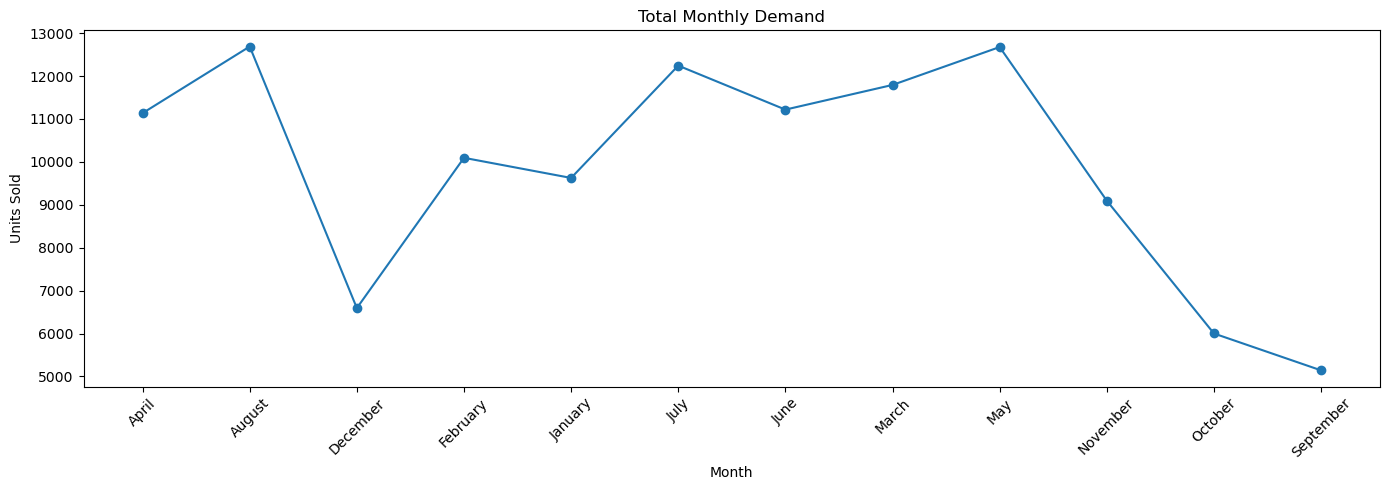

In [2]:
monthly_sales = (
    monthly_demand
    .groupby("order_month")["units_sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,5))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["units_sold"],
    marker="o"
)

plt.title("Total Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

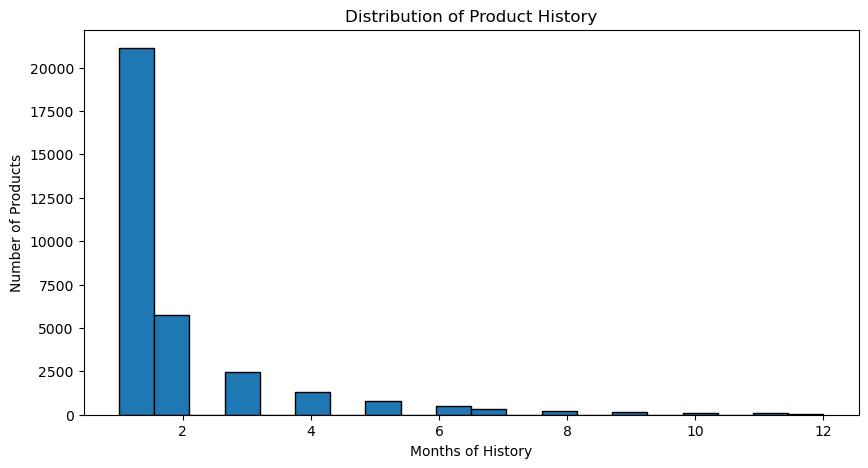

,product_id,months_of_history
0,00066f42aeeb9f3007548bb9d3f33c38,1
1,00088930e925c41fd95ebfe695fd2655,1
2,0009406fd7479715e4bef61dd91f2462,1
3,000b8f95fcb9e0096488278317764d19,1
4,000d9be29b5207b54e86aa1b1ac54872,1
...,...,...
32946,fff6177642830a9a94a0f2cba5e476d1,2
32947,fff81cc3158d2725c0655ab9ba0f712c,1
32948,fff9553ac224cec9d15d49f5a263411f,1
32949,fffdb2d0ec8d6a61f0a0a0db3f25b441,3


In [9]:
history = (
    monthly_demand
    .groupby("product_id")
    .size()
    .reset_index(name="months_of_history")
)
plt.figure(figsize=(10,5))

plt.hist(
    history["months_of_history"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Months of History")
plt.ylabel("Number of Products")
plt.title("Distribution of Product History")

plt.show()
history.sort_values(
    "months_of_history",
    ascending=False
).head(20)

In [60]:
eligible_products = history[
    history["months_of_history"] >= 8
]

print("Eligible Products:", len(eligible_products))
percentage = (
    len(eligible_products) /
    history.shape[0]
) * 100

print(f"{percentage:.2f}% of products have 10 months of history")

Eligible Products: 658
2.00% of products have 10 months of history


In [61]:
top_products = (
    monthly_demand
    .groupby("product_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    536
99a4788cb24856965c36a24e339b6058    528
422879e10f46682990de24d770e7f83d    508
389d119b48cf3043d311335e499d9c6b    406
368c6c730842d78016ad823897a372db    398
53759a2ecddad2bb87a079a1f1519f73    391
d1c427060a0f73f6b889a5c7c61f2ac4    357
53b36df67ebb7c41585e8d54d6772e08    327
154e7e31ebfa092203795c972e5804a6    295
3dd2a17168ec895c781a9191c1e95ad7    278
2b4609f8948be18874494203496bc318    275
7c1bd920dbdf22470b68bde975dd3ccf    242
a62e25e09e05e6faf31d90c6ec1aa3d1    228
bb50f2e236e5eea0100680137654686c    210
e0d64dcfaa3b6db5c54ca298ae101d05    202
5a848e4ab52fd5445cdc07aab1c40e48    197
e53e557d5a159f5aa2c5e995dfdf244b    192
35afc973633aaeb6b877ff57b2793310    189
42a2c92a0979a949ca4ea89ec5c7b934    185
b532349fe46b38fbc7bb3914c1bdae07    181
Name: units_sold, dtype: int64

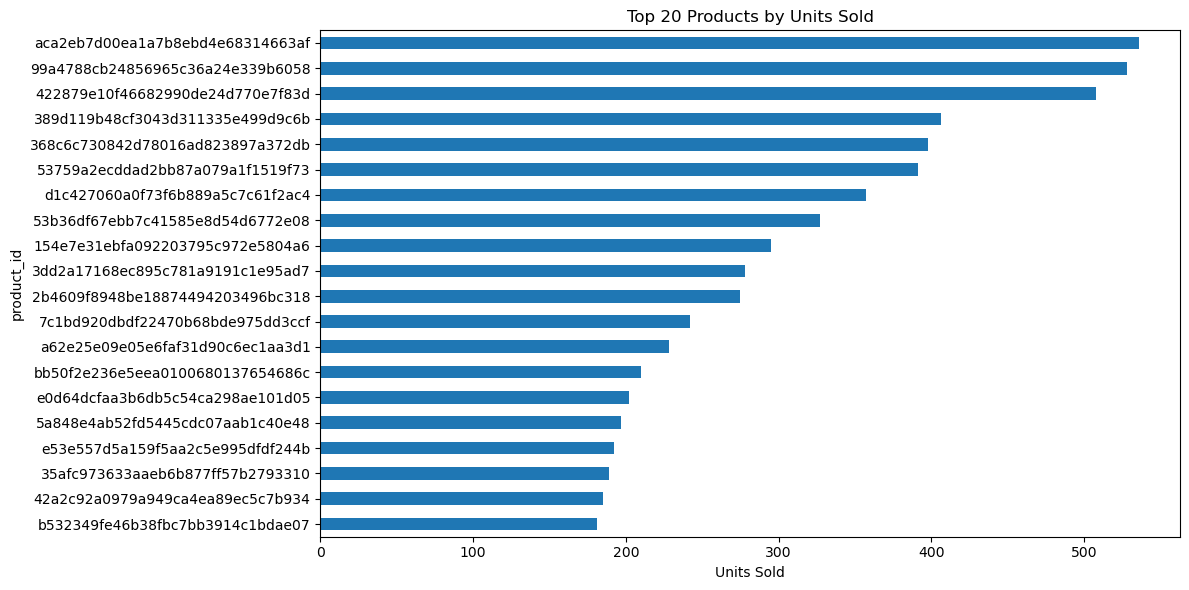

In [62]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 20 Products by Units Sold")
plt.xlabel("Units Sold")

plt.tight_layout()
plt.show()

In [63]:
monthly_demand = monthly_demand.sort_values(
    ["product_id","order_month"])
monthly_demand_eligible = monthly_demand[
monthly_demand["product_id"].isin(eligible_products["product_id"])
]

monthly_demand_eligible["MA_3"] = (
    monthly_demand_eligible
    .groupby("product_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(3).mean()
    )
)
monthly_demand_eligible["MA_6"] = (
    monthly_demand_eligible
    .groupby("product_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(6).mean()
    )
)
monthly_demand_eligible



C:\Users\RohanS\AppData\Local\Temp\ipykernel_2732\4254530837.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_demand_eligible["MA_3"] = (
C:\Users\RohanS\AppData\Local\Temp\ipykernel_2732\4254530837.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_demand_eligible["MA_6"] = (


,product_id,order_month,units_sold,MA_3,MA_6
131,00ba6d766f0b1d7b78a5ce3e1e033263,August,1,NaN,NaN
132,00ba6d766f0b1d7b78a5ce3e1e033263,December,2,NaN,NaN
133,00ba6d766f0b1d7b78a5ce3e1e033263,February,2,NaN,NaN
134,00ba6d766f0b1d7b78a5ce3e1e033263,January,2,1.666667,NaN
135,00ba6d766f0b1d7b78a5ce3e1e033263,July,2,2.000000,NaN
...,...,...,...,...,...
60635,ff7fccf8513f360157f0660fe51d1d88,July,1,1.666667,NaN
60636,ff7fccf8513f360157f0660fe51d1d88,June,2,1.666667,NaN
60637,ff7fccf8513f360157f0660fe51d1d88,March,3,1.333333,NaN
60638,ff7fccf8513f360157f0660fe51d1d88,October,1,2.000000,1.833333


In [64]:
forecast_table = (
    monthly_demand_eligible
    .groupby("product_id")
    .tail(1)[
        [
            "product_id",
            "order_month",
            "units_sold",
            "MA_3",
            "MA_6"
        ]
    ]
)
forecast_table = forecast_table.rename(
    columns={
        "MA_3":"forecast_ma3",
        "MA_6":"forecast_ma6",
        "units_sold":"last_month_sales"
    }
)
forecast_table.to_csv(
    r"C:\Users\RohanS\Documents\data retail\forecast_table.csv",
    index=False)

In [65]:
monthly_demand

,product_id,order_month,units_sold
0,00066f42aeeb9f3007548bb9d3f33c38,May,1
1,00088930e925c41fd95ebfe695fd2655,December,1
2,0009406fd7479715e4bef61dd91f2462,December,1
3,000b8f95fcb9e0096488278317764d19,August,2
4,000d9be29b5207b54e86aa1b1ac54872,April,1
...,...,...,...
60791,fff9553ac224cec9d15d49f5a263411f,October,1
60792,fffdb2d0ec8d6a61f0a0a0db3f25b441,April,2
60793,fffdb2d0ec8d6a61f0a0a0db3f25b441,August,2
60794,fffdb2d0ec8d6a61f0a0a0db3f25b441,May,1


In [107]:

inventory_kpi = (
    monthly_demand_eligible
    .groupby("product_id")
    .agg(
        Avg_Monthly_Demand=("units_sold", "mean"),
        Std_Monthly_Demand=("units_sold", "std"),
        Min_Monthly_Demand=("units_sold", "min"),
        Max_Monthly_Demand=("units_sold", "max"),
        Total_Demand=("units_sold", "sum"),
        Months_Sold=("units_sold", "count"),
        Latest_Month_Demand=("units_sold", "last")
    )
    .sort_values("Total_Demand",ascending=False)
    .reset_index()
)
inventory_kpi["Demand_CV"] = (
    inventory_kpi["Std_Monthly_Demand"] /
    inventory_kpi["Avg_Monthly_Demand"]
)

inventory_kpi["Demand_CV"] = (
    inventory_kpi["Demand_CV"]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)
inventory_kpi["Demand_Trend"] = np.where(
    inventory_kpi["Latest_Month_Demand"] >
    inventory_kpi["Avg_Monthly_Demand"] * 1.10,
    "Increasing",
    np.where(
        inventory_kpi["Latest_Month_Demand"] <
        inventory_kpi["Avg_Monthly_Demand"] * 0.90,
        "Declining",
        "Stable"
    )
)
inventory_kpi = inventory_kpi.round({
    "Avg_Monthly_Demand":2,
    "Std_Monthly_Demand":2,
    "Demand_CV":2
})

inventory_kpi

,product_id,Avg_Monthly_Demand,Std_Monthly_Demand,Min_Monthly_Demand,Max_Monthly_Demand,Total_Demand,Months_Sold,Latest_Month_Demand,Demand_CV,Demand_Trend
0,aca2eb7d00ea1a7b8ebd4e68314663af,48.73,40.17,2,124,536,11,5,0.82,Declining
1,99a4788cb24856965c36a24e339b6058,44.00,24.40,18,93,528,12,25,0.55,Declining
2,422879e10f46682990de24d770e7f83d,42.33,23.04,12,97,508,12,38,0.54,Declining
3,389d119b48cf3043d311335e499d9c6b,33.83,19.62,9,87,406,12,20,0.58,Declining
4,368c6c730842d78016ad823897a372db,33.17,16.77,13,72,398,12,13,0.51,Declining
...,...,...,...,...,...,...,...,...,...,...
653,235e0d56841710b62daf088840a96ba8,1.12,0.35,1,2,9,8,1,0.31,Declining
654,03bb06cda40712fb8473f7962fb7d198,1.12,0.35,1,2,9,8,2,0.31,Increasing
655,bb48c8fda6bcf73c9a0178fd1a1a366d,1.12,0.35,1,2,9,8,2,0.31,Increasing
656,2d2600c283c0c1af0528fd84c14a2c28,1.00,0.00,1,1,8,8,1,0.00,Stable


In [109]:
avg_price = (
    fact_sales
    .groupby("product_id")["price"]
    .mean()
    .reset_index()
    .rename(columns={"price": "Avg_Price"})
)



In [110]:
inventory_kpi = inventory_kpi.merge(
    avg_price,
    on="product_id",
    how="left"
)

In [127]:
inventory_kpi["Annual_Demand_Value"] = (
    inventory_kpi["Total_Demand"] *
    inventory_kpi["Avg_Price"]
)
inventory_kpi = inventory_kpi.sort_values(
    by="Annual_Demand_Value",
    ascending=False
).reset_index(drop=True)
inventory_kpi["Cumulative_Value"] = (
    inventory_kpi["Annual_Demand_Value"]
    .cumsum()
)
total_value = inventory_kpi["Annual_Demand_Value"].sum()
inventory_kpi["Cumulative_Percentage"] =round((
    inventory_kpi["Cumulative_Value"] /
    total_value
) * 100,2)
def product_class(cp):

    if cp <= 80:
        return "A"

    elif cp <= 95:
        return "B"

    else:
        return "C"

inventory_kpi["product_Class"] = (
    inventory_kpi["Cumulative_Percentage"]
    .apply(product_class)
)
inventory_kpi.drop(columns="ABC_Class")
def xyz_class(cv):

    if cv <= 0.50:
        return "X"

    elif cv <= 1.00:
        return "Y"

    else:
        return "Z"
inventory_kpi["XYZ_Class"] = (
    inventory_kpi["Demand_CV"]
    .apply(xyz_class)
)
inventory_kpi["ABC_XYZ_Class"] = (
    inventory_kpi["ABC_Class"] +
    inventory_kpi["XYZ_Class"]
)
inventory_kpi.to_csv(
    r"C:\Users\RohanS\Documents\data retail processed\inventory_kpi.csv",
    index=False)

In [129]:
matrix_summary = (
    inventory_kpi
    .groupby("ABC_XYZ_Class")
    .size()
    .reset_index(name="No_of_Products")
)

matrix_summary
inventory_kpi

,product_id,Avg_Monthly_Demand,Std_Monthly_Demand,Min_Monthly_Demand,Max_Monthly_Demand,Total_Demand,Months_Sold,Latest_Month_Demand,Demand_CV,Demand_Trend,Avg_Price,Annual_Demand_Value,Cumulative_Value,Cumulative_Percentage,ABC_Class,product_Class,XYZ_Class,ABC_XYZ_Class
0,bb50f2e236e5eea0100680137654686c,17.50,9.19,2,34,210,12,11,0.53,Declining,327.666667,68810.00,68810.00,2.42,A,A,Y,AY
1,6cdd53843498f92890544667809f1595,13.25,5.07,7,21,159,12,7,0.38,Declining,350.816981,55779.90,124589.90,4.39,A,A,X,AX
2,d1c427060a0f73f6b889a5c7c61f2ac4,29.75,15.26,11,63,357,12,11,0.51,Declining,137.650980,49141.40,173731.30,6.12,A,A,Y,AY
3,99a4788cb24856965c36a24e339b6058,44.00,24.40,18,93,528,12,25,0.55,Declining,88.211477,46575.66,220306.96,7.76,A,A,Y,AY
4,3dd2a17168ec895c781a9191c1e95ad7,34.75,22.27,6,72,278,8,52,0.64,Increasing,149.935971,41682.20,261989.16,9.23,A,A,Y,AY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653,83b23a333b811855258c5ec9431f6d3e,1.44,0.88,1,3,13,9,1,0.61,Declining,16.000000,208.00,2838993.04,99.97,C,C,Y,CY
654,7ae8d9b8eca8a6daf066e53ddc7034d3,1.50,0.53,1,2,12,8,2,0.36,Increasing,16.900000,202.80,2839195.84,99.98,C,C,X,CX
655,2083a6feb4bbb31f6abc92fc24e468c0,2.90,2.08,1,8,29,10,4,0.72,Increasing,6.931034,201.00,2839396.84,99.99,C,C,Y,CY
656,25d6edcd216a9ee579f19f92d694f7d5,1.75,1.16,1,4,14,8,1,0.67,Declining,13.682143,191.55,2839588.39,99.99,C,C,Y,CY
